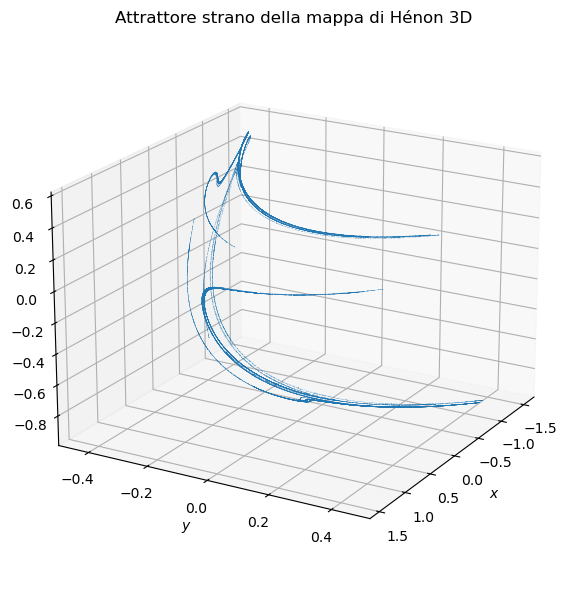

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessario per la proiezione 3D

# Parametri del sistema (mappa di Hénon 3D)
alpha = 1.07
beta = 0.3

def henon3d_step(state, alpha=alpha, beta=beta):
    """
    Un passo della mappa di Hénon 3D.
    state: array-like [x, y, z]
    """
    x, y, z = state
    x_next = 1.0 - alpha * x**2 + z
    y_next = -beta * x
    z_next = beta * x + y
    return np.array([x_next, y_next, z_next])

# Parametri della simulazione
N_total = 100_000     # numero totale di iterazioni
N_transient = 5_000   # iterazioni da scartare (transiente)
dt_sample = 1         # ogni quanti passi salvare un punto (=1 → tutti)

# Condizione iniziale
state = np.array([0.1, 0.0, 0.0], dtype=float)

# Lista per salvare i punti dopo il transiente
trajectory = []

for n in range(N_total):
    state = henon3d_step(state)
    if n >= N_transient and (n - N_transient) % dt_sample == 0:
        trajectory.append(state.copy())

trajectory = np.array(trajectory)
x = trajectory[:, 0]
y = trajectory[:, 1]
z = trajectory[:, 2]

# Visualizzazione 3D dell'attrattore
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# marker piccolo per l'effetto "nuvola" dell'attrattore
ax.scatter(x, y, z, s=0.1, linewidths=0)

ax.set_title("Attrattore strano della mappa di Hénon 3D")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")

# opzionale: modifica dell'angolo di vista
ax.view_init(elev=20, azim=30)

plt.tight_layout()
plt.show()
